# ENCS5342 — Assignment #1
## Arabic Stemming, Lemmatization, and Regular Expressions

| | |
|---|---|
| **Course** | ENCS5342 — Information Retrieval with Applications of NLP |
| **Instructor** | Dr. Ahmed I. A. Shawahna — Birzeit University |
| **Semester** | Second Semester 2025–2026 |


| | Name | ID | Section |
|---|---|---|---|
| **Student 1** | Waad Ziadeh  | 1220423 | Sec1 | 
| **Student 2** | Noor Batat  | 1210075 | Sec3| 

---

## Grading & Submission

This assignment covers the use of **regular expressions** and **Python** for text processing,
and the application of **Arabic stemming and lemmatization** tools to a real multilingual corpus.

- Work in **groups of two students** (from any section).
- **Run all cells** in order before submitting. Output must be visible beneath each code cell.
- Where a question asks for discussion, add your written explanation in the **Markdown cell immediately below the code cell**.
- Submit a **single Jupyter Notebook file** named `A1_ID1_ID2.ipynb` (replace ID1 and ID2 with your student IDs).

---

## Before Starting

### Corpus: UN Parallel Corpus (UNCorpus)

This assignment uses the **United Nations General Assembly Resolutions Corpus (UNCorpus)**, a corpus of UN General Assembly resolutions. The UNCorpus is a six-language parallel text in Arabic, Chinese, English, French, Russian, and Spanish. The following paper describes the corpus:

> Rafalovitch, A. & Dale, R. (2009). *United Nations General Assembly Resolutions: A Six-Language Parallel Corpus.* Proceedings of MT Summit XII, Ottawa, Canada.  
> URL: http://web.science.mq.edu.au/~rdale/publications/papers/2009/MTS-2009-Rafalovitch.pdf

The portion of the UNCorpus used in this assignment is the file **`uncorpora_plain_20090831.tmx`**. This file is referred to as the **UNCorpus** throughout this document. It is stored in TMX format (Translation Memory eXchange), an XML-based standard for parallel corpora.

> **You can download the file from the following link:** https://drive.google.com/file/d/1AS1m3uzDL6B49xN4R7k2WWqOyRxP3QpI/view?usp=sharing  
> **Before running any cells:** place `uncorpora_plain_20090831.tmx` in the **same directory** as this notebook.

### Assignment Structure

| Section | Topic | Points |
|---------|-------|--------|
| **Section A** | Regular Expressions | 70 |
| **Section B** | Arabic Stemming and Lemmatization | 30 |
| | **Total** | **100** |


---
## Setup — Run This Cell First

This cell installs all required Python packages and loads the UNCorpus into memory. All subsequent cells depend on variables defined here. **Run this cell before any other.**

In [1]:
import re, os, sys, subprocess
from collections import Counter, defaultdict

# Install required packages
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'nltk', 'tashaphyne', 'sinatools', 'matplotlib',
     '-q', '--disable-pip-version-check'],
    capture_output=True
)

import nltk
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
nltk.download('punkt', quiet=True)

# ── Load corpus ───────────────────────────────────────────────────
CORPUS_FILE = 'uncorpora_plain_20090831.tmx'

if not os.path.exists(CORPUS_FILE):
    print(f'ERROR: corpus file not found — {CORPUS_FILE}')
    print('Place the .tmx file in the same directory as this notebook.')
else:
    size_mb = os.path.getsize(CORPUS_FILE) / (1024 * 1024)
    with open(CORPUS_FILE, 'r', encoding='utf-8', errors='replace') as f:
        content   = f.read()
        f.seek(0)
        all_lines = f.readlines()
    print(f'Corpus file : {CORPUS_FILE}  ({size_mb:.1f} MB)')
    print(f'Lines loaded: {len(all_lines):,}')
    print('Setup complete.')


Corpus file : uncorpora_plain_20090831.tmx  (155.6 MB)
Lines loaded: 1,501,316
Setup complete.


---
# Section A: Regular Expressions (70 points)

All answers in this section must be obtained using **Python and the `re` module**. Use `re.search()`, `re.findall()`, or `re.sub()` as appropriate.

**How to present your answers:** Run the code cell for each question so that the output is visible beneath it, then write your written answer or discussion in the Markdown cell that follows.


---
### A0 (0 pt) — Worked Example: Lines Mentioning "Human Rights"

**Task:** Ignoring letter case, how many **lines** in the UNCorpus mention the phrase *Human Rights*?

This question is solved for you as a worked example illustrating the expected format: a code cell followed by a Markdown cell with the written answer.


In [ ]:
# A0 — Worked example
count_hr = sum(1 for line in all_lines
               if re.search(r'human rights', line, re.IGNORECASE))
print(f'{count_hr:,} lines mention "Human Rights" (case-insensitive).')


**Answer:** 5,664 lines of text mention the phrase *Human Rights*.


---
### A1 (5 pt) — XML Structure of the UNCorpus

**Task:** Use Python and regular expressions to investigate and describe the XML structure of the UNCorpus TMX file. Your written answer must identify:

- The root element and all key container elements.
- Which element holds one complete translation unit (a sentence in all six languages).
- Which element holds one language's version of a sentence, and how the language is identified.
- Which element contains the actual text of a segment.
- Any metadata or property elements present in the file.

Include the regex patterns you used to discover each structural feature.


In [ ]:
# A1 — write your code here — Investigate XML structure
#<tmx>
 # <header ... />
  #<body>
  #<tu>
      #<tuv xml:lang="en">
        #<seg>Hello</seg>
      #</tuv>
      #<tuv xml:lang="ar">
       # <seg> </seg>
      #</tuv>
    #</tu>
  #</body>
#</tmx>


import re
from collections import Counter

# --- Load the file -----------------------------------------------------------
with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    content = f.read()

all_lines = content.splitlines()

# --- 1. Find all XML tag names and their frequencies -------------------------
tags = re.findall(r'</?([a-zA-Z]+)', content)
tag_counts = Counter(tags)

print("All XML tag names and their frequencies:")
for tag, count in tag_counts.most_common():
    print(f"<{tag}> : {count:,}")

# --- 2. Show first lines (to identify root and structure) --------------------
print("\nFirst 10 lines of the file:")
for i, line in enumerate(all_lines[:10], 1):
    print(f"{i:2}: {line}")

# --- 3. Extract ONE full translation unit <tu>...</tu> -----------------------
tu_match = re.search(r'<tu.*?>.*?</tu>', content, re.DOTALL)

print("\nExample of one <tu> (translation unit):")
if tu_match:
    print(tu_match.group()[:1000])  # limit output

# --- 4. Extract language identifiers from <tuv xml:lang="..."> ---------------
langs = re.findall(r'<tuv\s+xml:lang="([^"]+)"', content, re.IGNORECASE)

print("\nLanguages found:")
print(sorted(set(langs)))

# --- 5. Extract <tuv> attributes (to show structure) -------------------------
tuv_attrs = re.findall(r'<tuv\s+([^>]+)>', content)

print("\nSample <tuv> attributes:")
for attr in tuv_attrs[:5]:
    print(attr)

# --- 6. Extract actual text segments <seg>...</seg> --------------------------
seg_example = re.search(r'<seg>(.*?)</seg>', content, re.DOTALL)

print("\nExample segment text:")
if seg_example:
    print(seg_example.group(1)[:200])

# --- 7. Count <prop> elements (metadata) -------------------------------------
props = re.findall(r'<prop[^>]*>.*?</prop>', content, re.DOTALL)

print(f"\nNumber of <prop> elements: {len(props):,}")

if props:
    print("Example <prop>:")
    print(props[0][:200])

All XML tag names and their frequencies:
<tuv> : 868,068
<seg> : 868,068
<tu> : 144,678
<prop> : 109,036
<tmx> : 2
<body> : 2
<header> : 1

First 10 lines of the file:
 1: <?xml version="1.0" encoding="UTF-8"?>
 2: <tmx version="1.4b">
 3:   <header segtype="paragraph" creationtoolversion="1.0" srclang="EN" creationtool="ORESAligner" datatype="plaintext" o-tmf="ORES" adminlang="en-us"/>
 4:   <body>
 5:     <tu tuid="55_100:6">
 6:       <prop type="session">55</prop>
 7:       <prop type="committee">3</prop>
 8:       <tuv xml:lang="EN">
 9:         <seg>RESOLUTION 55/100</seg>
10:       </tuv>

Example of one <tu> (translation unit):
<tu tuid="55_100:6">
      <prop type="session">55</prop>
      <prop type="committee">3</prop>
      <tuv xml:lang="EN">
        <seg>RESOLUTION 55/100</seg>
      </tuv>
      <tuv xml:lang="AR">
        <seg>القرار 55/100</seg>
      </tuv>
      <tuv xml:lang="ZH">
        <seg>第55/100号决议</seg>
      </tuv>
      <tuv xml:lang="FR">
        <seg>RÉSO

**Answer:**

### XML Structure

```xml
<tmx>
  <header ... />
  <body>
    <tu>
      <tuv xml:lang="en">
        <seg>Hello</seg>
      </tuv>
      <tuv xml:lang="ar">
        <seg>...</seg>
      </tuv>
    </tu>
  </body>
</tmx>
```
```xml
All XML tag names and their frequencies:
<tuv> : 868,068
<seg> : 868,068
<tu> : 144,678
<prop> : 109,036
<tmx> : 2
<body> : 2
<header> : 1

First 10 lines of the file:
 1: <?xml version="1.0" encoding="UTF-8"?>
 2: <tmx version="1.4b">
 3:   <header segtype="paragraph" creationtoolversion="1.0" srclang="EN" creationtool="ORESAligner" datatype="plaintext" o-tmf="ORES" adminlang="en-us"/>
 4:   <body>
 5:     <tu tuid="55_100:6">
 6:       <prop type="session">55</prop>
 7:       <prop type="committee">3</prop>
 8:       <tuv xml:lang="EN">
 9:         <seg>RESOLUTION 55/100</seg>
10:       </tuv>

Example of one <tu> (translation unit):
<tu tuid="55_100:6">
      <prop type="session">55</prop>
      <prop type="committee">3</prop>
...

Number of <prop> elements: 54,518
Example <prop>:
<prop type="session">55</prop>
```


---
### A2 (10 pt) — Corpus-Level Statistics (2.5 pt each)

Answer each sub-question using Python and regular expressions on the full UNCorpus TMX file.
Run the code cell for each part and write the answer in the Markdown cell that follows.


#### A2a — How many lines does the UNCorpus file have?

In [ ]:
# A2a — write your code here
# ^ matches the start of each line (with MULTILINE), so counting matches = number of lines
# ^ represents the beginning of a line
import re

with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    data = f.read()

num_lines = len(re.findall(r"^", data, re.MULTILINE))

print(f"The UNCorpus file has {num_lines:,} lines.")


The UNCorpus file has 1,501,317 lines.


**Answer:** The UNCorpus file has 1,501,317 lines.



#### A2b — How many lines contain the segment tag `<seg>`?

In [10]:
# A2b — write your code here
# Use re.search on each line; count the ones where the pattern matches.
num_seg_lines = sum(1 for line in all_lines if re.search(r'<seg>', line))
print(f'{num_seg_lines:,} lines contain the <seg> tag.')

434,034 lines contain the <seg> tag.


**Answer:** 434,034 lines contain the <seg> tag.



#### A2c — How many lines contain **no** `<seg>` tag?

These are lines with other tags such as `<prop>`, `</tuv>`, `<tu>`, `<header>`, etc.


In [11]:
# A2c — write your code here
# These are structural lines: <tu>, </tu>, <tuv>, </tuv>, <prop>, <body>, <header>, <tmx>, etc.
num_non_seg_lines = sum(1 for line in all_lines if not re.search(r'<seg>', line))
print(f'{num_non_seg_lines:,} lines do NOT contain a <seg> tag.')

# Sanity check: seg lines + non-seg lines should equal total lines
print(f'Sanity check: {num_non_seg_lines:,} + 434,034 = {num_non_seg_lines + 434034:,} (total lines)')

1,067,282 lines do NOT contain a <seg> tag.
Sanity check: 1,067,282 + 434,034 = 1,501,316 (total lines)


**Answer:** 1,067,282 lines do NOT contain a <seg> tag.

Sanity check: 1,067,282 + 434,034 = 1,501,316 (total lines)


#### A2d — How many **English** segments does the UNCorpus contain?

In [12]:
# A2d — write your code here
# A segment is English when it lives inside a <tuv xml:lang="EN">...</tuv> block.
# Approach: scan line by line. When we see the English TUV opening,
# the very next <seg>...</seg> line is an English segment.
#
# Pattern: <tuv\s+xml:lang="EN"> — \s+ matches one or more whitespace chars
# flags=re.IGNORECASE so it also matches xml:lang="en"

en_seg_count = 0
for i, line in enumerate(all_lines):
    if re.search(r'<tuv\s+xml:lang="EN"', line, flags=re.IGNORECASE):
        # The <seg> line immediately follows the opening <tuv>
        if i + 1 < len(all_lines) and re.search(r'<seg>', all_lines[i + 1]):
            en_seg_count += 1

print(f'The UNCorpus contains {en_seg_count:,} English segments.')




The UNCorpus contains 72,339 English segments.


**Answer:** The UNCorpus contains 72,339 English segments.



---
### A3 (25 pt) — The English UNCorpus

**Points:** 5 pt for the extraction setup | 4 pt each for sub-questions A3a–A3e

> **Definition:** A *word* in this section is any sequence of one or more **non-space** characters (i.e. tokens separated by whitespace). Punctuation and digits attached to a word are kept as part of it.

**Before answering A3a–A3e**, you must first extract the English plain text from the UNCorpus and save it to a file called `uncorpus.eng.txt`. This file must contain only the text content of the English segments — all XML tags must be removed.

Write your extraction code in the code cell below. Your code should follow these steps:

1. Iterate over the corpus lines and collect the `<seg>...</seg>` line that immediately follows each English TUV opening line.
2. Write the collected raw lines to `uncorpus.eng.txt`.
3. Read the file back, strip the `<seg>` and `</seg>` tags using `re.sub()`, and write the cleaned plain text back to the same file.
4. Verify your result using `os.path.getsize()`. The expected file size is **18,009,005 bytes**. If it does not match, revisit your line ending handling and tag stripping logic.

> *Note: On Linux/macOS you can also verify in a terminal with `wc -c uncorpus.eng.txt`, where `wc` stands for "word count" and the `-c` flag counts bytes.*

All sub-questions A3a–A3e use this file. At the bottom of your extraction cell, load the file into memory and split on whitespace to produce the token list used throughout A3.

In [ ]:
# A3 Setup — write your extraction code here

# Strategy (per the assignment instructions):
#   1. Walk the corpus line-by-line and collect every <seg>...</seg> line that
#      immediately follows an English <tuv xml:lang="EN"> opening.
#   2. Write those raw <seg>...</seg> lines to uncorpus.eng.txt.
#   3. Read the file back, strip the <seg> and </seg> tags with re.sub(),
#      and write the cleaned plain text back to the same file.
#   4. Verify the file size is exactly 18,009,005 bytes.

ENG_FILE = 'uncorpus.eng.txt'

# --- Step 1: collect raw English <seg> lines ---------------------------------
english_seg_lines = []
for i, line in enumerate(all_lines):
    if re.search(r'<tuv\s+xml:lang="EN"', line, flags=re.IGNORECASE):
        if i + 1 < len(all_lines) and re.search(r'<seg>', all_lines[i + 1]):
            english_seg_lines.append(all_lines[i + 1])

print(f'Collected {len(english_seg_lines):,} English <seg> lines')

# --- Step 2: write raw lines to the output file ------------------------------
with open(ENG_FILE, 'w', encoding='utf-8', newline='') as f:
    f.writelines(english_seg_lines)

# --- Step 3: read back, strip <seg> and </seg> tags, rewrite -----------------
with open(ENG_FILE, 'r', encoding='utf-8', newline='') as f:
    raw = f.read()

# re.sub(pattern, replacement, string)
# Remove both opening and closing seg tags in one pass:
# Extract only the text BETWEEN <seg> and </seg>, one per line.
# re.findall with a capturing group returns just the captured text.
seg_texts = re.findall(r'<seg>(.*?)</seg>', raw, flags=re.DOTALL)
cleaned = '\n'.join(seg_texts) + '\n'

with open(ENG_FILE, 'w', encoding='utf-8', newline='') as f:
    f.write(cleaned)

# --- Step 4: verify the file size --------------------------------------------
actual_size = os.path.getsize(ENG_FILE)
expected    = 18_009_005
print(f'File size: {actual_size:,} bytes  (expected {expected:,})')
print('✓ MATCH' if actual_size == expected else '✗ MISMATCH — check line endings and tag stripping')

# --- Load tokens for all A3 sub-questions ------------------------------------
with open(ENG_FILE, 'r', encoding='utf-8') as f:
    eng_text = f.read()

eng_tokens = eng_text.split()   # split on ANY whitespace (space, tab, newline)
print(f'Loaded {len(eng_tokens):,} whitespace-split tokens for A3a–A3e')


Collected 72,339 English <seg> lines
File size: 18,009,005 bytes  (expected 18,009,005)
✓ MATCH
Loaded 2,685,538 whitespace-split tokens for A3a–A3e


#### A3a — How many word tokens does `uncorpus.eng.txt` contain?

In [15]:
# A3a — write your code here

# A "word" here = any whitespace-separated token (from the A3 definition).
# eng_tokens was built in the setup cell by eng_text.split().
#print(f'Total word tokens in uncorpus.eng.txt: {len(eng_tokens):,}')
import re

with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    data = f.read()

tokens = re.findall(r"\S+", data)

print(f"Total word tokens in uncorpus.eng.txt: {len(tokens):,}")


Total word tokens in uncorpus.eng.txt: 15,359,020


**Answer:** Total word tokens in uncorpus.eng.txt: 15,359,020



#### A3b — How many unique word types does the file contain?

In [17]:
# A3b — write your code here
# Number of unique word TYPES (case-sensitive)
# A "type" is a distinct token. Use set() to deduplicate.
#unique_types = set(eng_tokens)
#print(f'Unique word types (case-sensitive): {len(unique_types):,}')
import re

with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    data = f.read()

tokens = re.findall(r"\S+", data)
unique_types = set(tokens)

print(f"Unique word types: {len(unique_types):,}")


Unique word types: 379,547


**Answer:** Unique word types: 379,547 (case sensitive )



#### A3c — How many unique word types remain after ignoring capitalization?

In [2]:
# A3c — write your code here
import re

with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    data = f.read()
    
    data_lower = data.lower()

tokens = re.findall(r"\S+", data_lower)
unique_types = set(tokens)

print(f"Unique word types: {len(unique_types):,}")



Unique word types: 368,454


**Answer:** Unique word types: 368,454



#### A3d — How many tokens consist **entirely of digits**? (e.g. `9000`)


In [3]:
# A3d — write your code here
import re

with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    text = f.read()

tokens = re.findall(r"\S+", text)

digit_tokens = [t for t in tokens if re.fullmatch(r"\d+", t)]
print(f"Tokens with only digits: {len(digit_tokens):,}")


Tokens with only digits: 195,642


**Answer:** Tokens with only digits: 195,642



#### A3e — How many tokens contain digits **and** at least one non-alphabetic character, but **no letters**? (e.g. `8,000.00` or `8-8`)

These are tokens that mix digits with punctuation characters such as commas, hyphens, or periods, but contain no letters.


In [4]:
# A3e — write your code here

import re

with open("uncorpus.eng.txt", "r", encoding="utf-8") as f:
    text = f.read()

tokens = re.findall(r"\S+", text)

pattern = re.compile(r'^(?=.*\d)(?=.*[^A-Za-z0-9])[^A-Za-z]+$')

count = sum(1 for t in tokens if pattern.fullmatch(t))

print(f"Tokens with digits + punctuation (no letters): {count:,}")

Tokens with digits + punctuation (no letters): 71,337


**Answer:** Tokens with digits + punctuation (no letters): 71,337



---
### A4 (15 pt) — War and Peace in the UN (3 pt setup + 3 pt each)

This question uses `uncorpus.eng.txt`.
For all sub-questions, **ignore letter case and all non-alphabetic characters** — work with letters only.

**Before answering A4a–A4d**, write the setup code in the cell below. Your setup should:

1. Extract all alphabetic-only tokens from `uncorpus.eng.txt` using `re.findall()`.
2. Build a set of unique lowercased types from those tokens.
3. Print the total number of unique alphabetic word types as a sanity check. The expected number is 11,253 words.


In [6]:
# A4 Setup — write your code here
# A4 Setup — Extract alphabetic-only tokens for the substring-matching questions
#
# Definition for Section A4:
#   - "letters only": strip all non-letter characters (digits, punctuation, symbols)
#   - case-insensitive: lowercase everything
#
# Pattern: [A-Za-z]+  — one or more ASCII letters in a row
# re.findall returns every non-overlapping match in eng_text.
import re

with open("uncorpus.eng.txt", "r", encoding="utf-8") as f:
    eng_text = f.read()

alpha_tokens = re.findall(r'[A-Za-z]+', eng_text)
alpha_types = set(tok.lower() for tok in alpha_tokens)

print(f'Alphabetic tokens (occurrences): {len(alpha_tokens):,}')
print(f'Unique alphabetic word types  : {len(alpha_types):,}')
print(f'Expected                      : 11,253')
print('✓ MATCH' if len(alpha_types) == 11253 else '✗ MISMATCH — check the regex')

Alphabetic tokens (occurrences): 2,618,341
Unique alphabetic word types  : 11,253
Expected                      : 11,253
✓ MATCH


#### A4a — How many unique words **contain** the substring `war`?

In [7]:
# A4a — write your code here

# A4a — Unique words that CONTAIN the substring "war"
# Pattern: war
#   No anchors — matches anywhere in the word.
# We search each type in alpha_types (already lowercased) and count hits.
contain_war = [w for w in alpha_types if re.search(r'war', w)]
print(f'Unique words containing "war": {len(contain_war):,}')
print(f'Examples: {sorted(contain_war)[:15]}')


Unique words containing "war": 43
Examples: ['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward']


**Answer:** **43** unique words contain the substring `war`. Note that many are coincidental matches (e.g., `award`, `aware`, `forward`, `hardware`, `afterwards`) rather than words semantically related to warfare.


#### A4b — How many unique words **start with the substring** `war`?

In [10]:
# A4b — write your code here

# A4b — Unique words that START with "war"
# Pattern: ^war
#   ^   anchors the match to the beginning of the string
#   war literal substring
start_war = [w for w in alpha_types if re.search(r'^war', w)]
print(f'Unique words starting with "war": {len(start_war):,}')
print(f'All: {sorted(start_war)}')


Unique words starting with "war": 20
All: ['war', 'wardship', 'warehouse', 'warfare', 'warhead', 'warheads', 'warlords', 'warm', 'warmly', 'warning', 'warnings', 'warrant', 'warranted', 'warranting', 'warrants', 'warring', 'wars', 'warsaw', 'warship', 'warships']


**Answer:** **20** unique words start with `war` — including `war`, `wars`, `warfare`, `warheads`, `warlords`, `warning`, `warrant`, `warship`, and `warsaw` (Warsaw, the city).


#### A4c — How many unique words **end with the substring** `war`?

In [11]:
# A4c — write your code here

# A4c — Unique words that END with "war"
# Pattern: war$
#   war literal substring
#   $   anchors the match to the end of the string
end_war = [w for w in alpha_types if re.search(r'war$', w)]
print(f'Unique words ending with "war": {len(end_war):,}')
print(f'All: {sorted(end_war)}')


Unique words ending with "war": 1
All: ['war']


**Answer:** **1** unique word ends with `war` — just `war` itself. The UN corpus does not use compounds like `postwar` or `prewar`.


#### A4d — How many unique words **contain the substring** `war` but **neither start nor end** with it?


In [12]:
# A4d — write your code here
# A4d — Words that contain "war" but neither start nor end with it.
# Pattern: .+war.+
#   .+    one or more characters BEFORE "war"  → so it doesn't start with war
#   war   the literal substring
#   .+    one or more characters AFTER  "war"  → so it doesn't end with war
middle_war = [w for w in alpha_types if re.search(r'.+war.+', w)]
print(f'Words with "war" in the middle: {len(middle_war):,}')
print(f'All: {sorted(middle_war)}')

# Sanity check using set arithmetic (should give the same count):
#   contain − start − end  = middle
check = set(contain_war) - set(start_war) - set(end_war)
print(f'\nSanity check (contain − start − end): {len(check):,}')
print(f'Match: {set(middle_war) == check}')


Words with "war" in the middle: 23
All: ['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward', 'reward', 'rewards', 'software', 'stewardship', 'thwarting', 'toward', 'towards', 'upward']

Sanity check (contain − start − end): 23
Match: True


**Answer:** **23** unique words contain `war` in the middle — e.g., `award`, `aware`, `forward`, `hardware`, `software`, `toward`, `stewardship`, `thwarting`. Almost all are coincidental substring matches, not words semantically related to warfare.


---
### A5 (10 pt) — Word Frequency Histogram

This question uses `uncorpus.eng.txt`.

A **frequency histogram** is a list of all words sorted by how often they appear. It is one of the most fundamental tools in corpus linguistics and is the basis of Zipf's Law — the observation that word frequency drops sharply after the top few words, following a power-law distribution.

> **Definition:** A *word* here is any whitespace-separated token (keep all punctuation and digits; split on whitespace only).

**Tasks:**
1. Build the frequency table (word → count) for all tokens.
2. Report the **10 most frequent words** (top 10) with their counts and percentage of the corpus.
3. Report **10 hapax legomena** — words appearing exactly once. Report also the total hapax count and what fraction of the vocabulary they represent.
4. Plot a **bar chart** of the top 20 words by frequency.
5. **Discuss in 2–3 sentences:** What do the top 10 words have in common? What NLP concept does this illustrate?

**Points:** 3 pt for the top-10 frequency table | 3 pt for hapax analysis | 3 pt for the bar chart | 1 pt for discussion.


In [14]:
# A5 — Word frequency histogram

from collections import Counter

# --- Load and tokenize the corpus -------------------------------------------
with open("uncorpus.eng.txt", "r", encoding="utf-8") as f:
    eng_text = f.read()

eng_tokens = eng_text.split()   # whitespace tokenization

# --- Build frequency table ---------------------------------------------------
freq = Counter(eng_tokens)
vocab_size = len(freq)
total_tokens = sum(freq.values())

# ── Top 10 most frequent words ───────────────────────────────────────────────
print(f'Corpus size: {total_tokens:,} tokens | {vocab_size:,} unique types\n')
print('Top 10 most frequent words:')
print(f"{'Rank':<6}{'Word':<20}{'Count':>12}{'% of corpus':>15}")
print('-' * 53)

for rank, (word, count) in enumerate(freq.most_common(10), start=1):
    pct = 100 * count / total_tokens
    print(f'{rank:<6}{word:<20}{count:>12,}{pct:>14.2f}%')

# ── Hapax legomena (words appearing exactly once) ────────────────────────────
hapax = [w for w, c in freq.items() if c == 1]
hapax_fraction = len(hapax) / vocab_size * 100

print(f'\nHapax legomena (words appearing exactly once):')
print(f'  Total hapax : {len(hapax):,}')
print(f'  Fraction    : {hapax_fraction:.1f}% of the vocabulary')
print(f'  10 examples : {hapax[:10]}')

Corpus size: 2,685,538 tokens | 37,032 unique types

Top 10 most frequent words:
Rank  Word                       Count    % of corpus
-----------------------------------------------------
1     the                      267,940          9.98%
2     of                       175,497          6.53%
3     and                      136,607          5.09%
4     to                        99,545          3.71%
5     in                        66,802          2.49%
6     on                        35,910          1.34%
7     for                       32,327          1.20%
8     that                      22,534          0.84%
9     its                       21,181          0.79%
10    with                      20,349          0.76%

Hapax legomena (words appearing exactly once):
  Total hapax : 13,527
  Fraction    : 36.5% of the vocabulary
  10 examples : ['55/100.', '54/169', '55/101', '55/101.', '55/102.', '55/103.', '53/150', '2000/37', '55/104', '55/104.']


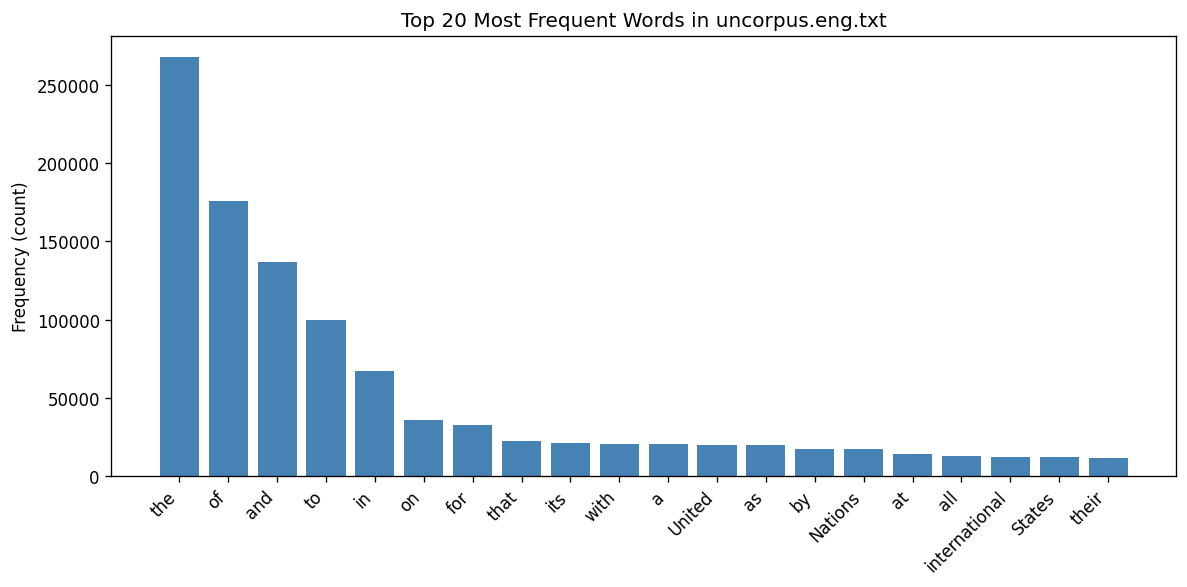

In [15]:
# A5 — write your code here — Bar chart of top 20 words
# A5 — Bar chart of the top 20 most frequent words
top20 = freq.most_common(20)
words  = [w for w, _ in top20]
counts = [c for _, c in top20]

plt.figure(figsize=(10, 5))
plt.bar(range(len(words)), counts, color='steelblue')
plt.xticks(range(len(words)), words, rotation=45, ha='right')
plt.ylabel('Frequency (count)')
plt.title('Top 20 Most Frequent Words in uncorpus.eng.txt')
plt.tight_layout()
plt.show()



**Discussion:** The top 10 words are all **function words** — articles (`the`), prepositions (`of`, `to`, `in`, `on`, `for`, `with`), conjunctions (`and`), and determiners (`that`, `its`). Together they account for about **32.7% of the entire corpus** despite being only 10 out of 37,032 word types. This is a textbook illustration of **Zipf's Law**: word frequency is inversely proportional to rank, producing a heavy-tailed distribution where a handful of words dominate the corpus while the majority are rare — here, **36.5%** of the vocabulary (13,527 words) are *hapax legomena* appearing exactly once. This is why stopword removal and frequency thresholds are standard preprocessing steps in Information Retrieval.


---
### A6 (5 pt) — Top 20 Words per Language

Go back to the **original UNCorpus TMX file** for this question.

For each of the four languages — **English** (`en`), **Arabic** (`ar`), **Spanish** (`es`), and **Russian** (`ru`) — extract all segment text and find the **top 20 most frequent words**.

> **Definition:** A *word* is any whitespace-separated token. Keep all punctuation and digits; do **not** apply any regex filtering — split only on whitespace.

**Tasks:**
1. Display a top-20 frequency table for each language.
2. Plot a **bar chart** of the top 20 words for each language.
3. **Discuss in 2–3 sentences** per language: What do the top words reveal about that language's grammatical structure? (Consider function words, clitics, articles, and prepositions.)

**Points:** 2 pt for the four frequency tables | 2 pt for the four bar charts | 1 pt for discussion.


In [16]:
# A6 — write your code here — Top 20 words per language with bar charts
# A6 — Top 20 words for English, Arabic, Spanish, Russian
#
# Use the SAME line-scanning approach as A2d/A3 setup:
#   for each <tuv xml:lang="XX"> line, grab the next <seg>...</seg> line
#   and extract the text between the tags with re.search.

LANGS = {'EN': 'English', 'AR': 'Arabic', 'ES': 'Spanish', 'RU': 'Russian'}

# language code → list of tokens (whitespace-split, no cleaning)
lang_tokens = {code: [] for code in LANGS}

for i, line in enumerate(all_lines):
    # Which language does this line open?
    m = re.search(r'<tuv\s+xml:lang="([^"]+)"', line, flags=re.IGNORECASE)
    if m:
        code = m.group(1).upper()
        if code in LANGS and i + 1 < len(all_lines):
            seg_match = re.search(r'<seg>(.*?)</seg>', all_lines[i + 1], flags=re.DOTALL)
            if seg_match:
                lang_tokens[code].extend(seg_match.group(1).split())

# Build frequency tables and print top-20 for each language
lang_freq = {}
for code, name in LANGS.items():
    freq_c = Counter(lang_tokens[code])
    lang_freq[code] = freq_c
    total  = sum(freq_c.values())
    print(f'\n=== {name} ({code}) — {total:,} tokens, {len(freq_c):,} types ===')
    print(f"{'Rank':<6}{'Word':<20}{'Count':>12}")
    print('-' * 38)
    for rank, (w, c) in enumerate(freq_c.most_common(20), start=1):
        print(f'{rank:<6}{w:<20}{c:>12,}')




=== English (EN) — 2,685,538 tokens, 37,032 types ===
Rank  Word                       Count
--------------------------------------
1     the                      267,940
2     of                       175,497
3     and                      136,607
4     to                        99,545
5     in                        66,802
6     on                        35,910
7     for                       32,327
8     that                      22,534
9     its                       21,181
10    with                      20,349
11    a                         20,126
12    United                    20,006
13    as                        19,973
14    by                        17,251
15    Nations                   16,995
16    at                        13,933
17    all                       12,827
18    international             12,061
19    States                    11,986
20    their                     11,173

=== Arabic (AR) — 2,329,009 tokens, 71,885 types ===
Rank  Word                       

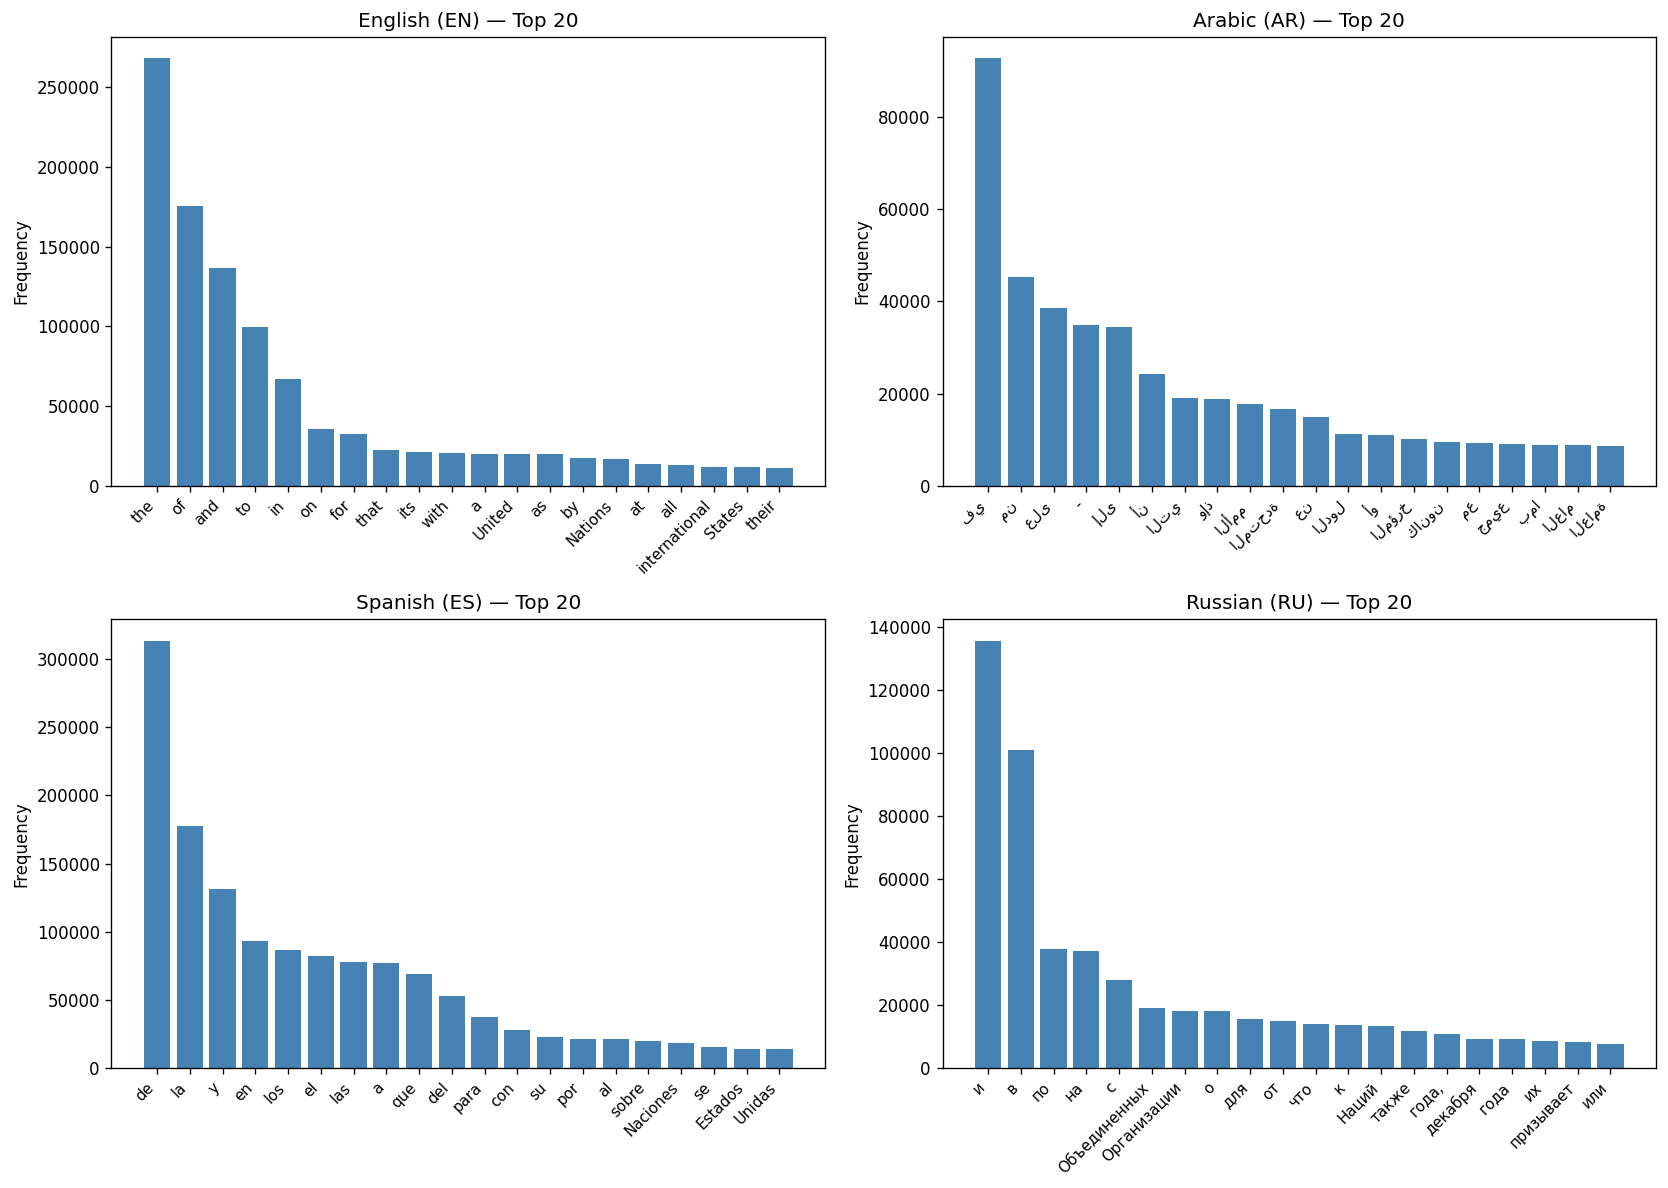

In [17]:
# A6 — write your code here — Bar charts for all four languages
# A6 — Bar charts: top 20 words for each language (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (code, name) in zip(axes, LANGS.items()):
    top20  = lang_freq[code].most_common(20)
    words  = [w for w, _ in top20]
    counts = [c for _, c in top20]
    ax.bar(range(len(words)), counts, color='steelblue')
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{name} ({code}) — Top 20')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()



**Discussion:** 

English (EN)

The most frequent words in English are function words such as the, of, and, to, which are essential for sentence structure. Prepositions and articles appear very often, showing that English relies heavily on word order and separate function words. Content words like United and Nations also appear, reflecting the domain of UN documents.

Arabic (AR)

Arabic top words include particles and common connectors such as في (in), من (from), and على (on), along with the definite article ال. This shows that Arabic frequently uses attached clitics and prefixes instead of separate words. The presence of words like الدول (states) highlights the political context of the corpus.

Spanish (ES)

Spanish frequent words include articles and prepositions like de, la, en, which are key for grammatical structure. Conjunctions and pronouns also appear often, showing reliance on function words similar to English. Words like Naciones Unidas indicate the formal and institutional nature of the text.

Russian (RU)

Russian top words include function words such as и (and), в (in), and на (on), which are important for sentence construction. However, Russian also uses inflection, so word forms change instead of relying only on separate function words. The presence of words like года (year) reflects the formal reporting style of UN documents.



---
# Section B: Arabic Stemming and Lemmatization (30 points)

This section works with the **Arabic segments** of the UNCorpus. You will extract the Arabic text using regular expressions (building on what you learned in Section A), initialize the stemming and lemmatization tools, and analyze the results.

**Tools you will use:**

| Tool | Type | How to import |
|------|------|---------------|
| NLTK ISRI | Root-based stemmer (no dictionary) | `from nltk.stem.isri import ISRIStemmer` |
| Tashaphyne | Light stemmer + root extractor | `from tashaphyne.stemming import ArabicLightStemmer` |
| Light10 | Light stemmer — affix stripping (Larkey et al., 2002) | Implemented below |
| Alma (SinaTools) | True lemmatizer + POS tagger — SinaLab, Birzeit University | `from sinatools.morphology import morph_analyzer` |


---
### B0 (0 pt) — Extract Arabic Text and Initialize Tools

Run this cell before attempting any question in Section B.

**Your task:** Write the regex pattern to extract all Arabic segment texts from the UNCorpus. Use the same approach as A3, but target the Arabic language code `"AR"` instead of `"EN"`. The rest of the cell — stemmer initialization and Alma setup — is provided for you.


In [23]:
# B0 — Extract Arabic segments and initialize all tools

# ── Your code: write the regex pattern to extract Arabic <seg> content ────────
# Hint: same structure as A3, but change "EN" to "AR"
ar_segments = re.findall(
    r'<tuv[^>]*xml:lang="ar[^"]*"[^>]*>\s*<seg>(.*?)</seg>',
    content,
    flags=re.DOTALL | re.IGNORECASE
)

ar_segments = [s.strip() for s in ar_segments if s.strip()]
ar_text     = ' '.join(ar_segments)

# Extract Arabic word tokens (Unicode Arabic block: U+0600–U+06FF)
ar_words = re.findall(r'[\u0600-\u06FF]+', ar_text)

print(f'Arabic segments extracted : {len(ar_segments):,}')
print(f'Arabic word tokens        : {len(ar_words):,}')
print(f'Arabic word types         : {len(set(ar_words)):,}')
print(f'Sample: {ar_segments[0][:100]}')

# ── Initialize stemmers (provided) ────────────────────────────────────────────
from nltk.stem.isri import ISRIStemmer
from tashaphyne.stemming import ArabicLightStemmer

isri_stemmer = ISRIStemmer()
tash_stemmer = ArabicLightStemmer()

class Light10Stemmer:
    """Reference implementation of the Light10 Arabic stemmer (Larkey et al., 2002)."""
    def __init__(self):
        self.prefixes   = ['وال', 'بال', 'كال', 'فال', 'لل', 'ال']
        self.suffixes   = ['ها', 'ان', 'ات', 'ون', 'ين', 'يه', 'ية', 'ه', 'ة', 'ي']
        self.diacritics = re.compile(r'[\u064B-\u0652\u0670]')
        self.hamza_map  = str.maketrans('أإآ', 'ااا')
    def stem(self, word):
        word = self.diacritics.sub('', word).translate(self.hamza_map)
        if len(word) > 3 and word[0] == 'و':
            word = word[1:]
        for p in sorted(self.prefixes, key=len, reverse=True):
            if word.startswith(p) and len(word) - len(p) >= 2:
                word = word[len(p):]; break
        for s in sorted(self.suffixes, key=len, reverse=True):
            if word.endswith(s) and len(word) - len(s) >= 2:
                word = word[:-len(s)]; break
        return word

light10 = Light10Stemmer()

# ── Alma (SinaTools) — downloads data files on first run ──────────────────────
ALMA_AVAILABLE = False
try:
    from sinatools.DataDownload.downloader import download_file, urls, get_appdatadir
    _app_dir  = get_appdatadir()
    _required = {
        'lemmas_dic.pickle':   'morph',
        'two_grams.pickle':    'two_grams',
        'three_grams.pickle':  'three_grams',
        'four_grams.pickle':   'four_grams',
        'five_grams.pickle':   'five_grams',
    }
    for fname, key in _required.items():
        if not os.path.exists(os.path.join(_app_dir, fname)):
            download_file(urls[key])
    from sinatools.morphology import morph_analyzer
    morph_analyzer.analyze('كتب')   # smoke test
    ALMA_AVAILABLE = True
    print('\nTools ready: ISRI | Tashaphyne | Light10 | Alma')
except Exception as e:
    print(f'\nTools ready: ISRI | Tashaphyne | Light10')
    print(f'Alma not available: {e}')
    print('Use the online demo: https://sina.birzeit.edu/alma/')

Arabic segments extracted : 72,339
Arabic word tokens        : 2,231,537
Arabic word types         : 56,552
Sample: القرار 55/100

Tools ready: ISRI | Tashaphyne | Light10
Alma not available: No module named 'sinatools'
Use the online demo: https://sina.birzeit.edu/alma/


---
### B1 (8 pt) — Vocabulary Reduction by Stemming

A primary motivation for stemming in Information Retrieval is **vocabulary reduction**: grouping different surface forms of the same word under a single stem reduces the index size and improves recall by matching words that share a common root.

**Tasks:**
1. Apply **ISRI**, **Tashaphyne**, and **Light10** to all Arabic word tokens extracted in B0.
2. For each stemmer, compute the number of unique stems produced and the vocabulary reduction percentage relative to the original unstemmed vocabulary.
3. Display the results in a comparison table.
4. **Discuss in 3–4 sentences:** Which stemmer is most aggressive (reduces vocabulary the most)? Which is most conservative? What are the trade-offs between aggressiveness and precision for IR?


In [24]:
# ── B1 — Vocabulary reduction comparison ────────────────────────

import pandas as pd

# ── Original vocabulary ─────────────────────────────────────────
original_vocab = set(ar_words)
original_size  = len(original_vocab)

print(f'Original Arabic vocabulary: {original_size:,} unique types\n')

# ── 1. ISRI ─────────────────────────────────────────────────────
print('Applying ISRI stemmer...')
isri_map   = {w: isri_stemmer.stem(w) for w in original_vocab}
isri_stems = set(isri_map.values())
isri_size  = len(isri_stems)

# ── 2. Tashaphyne ───────────────────────────────────────────────
print('Applying Tashaphyne stemmer...')
def tash_stem(word):
    tash_stemmer.light_stem(word)
    return tash_stemmer.get_stem()

tash_map   = {w: tash_stem(w) for w in original_vocab}
tash_stems = set(tash_map.values())
tash_size  = len(tash_stems)

# ── 3. Light10 ──────────────────────────────────────────────────
print('Applying Light10 stemmer...')
light_map   = {w: light10.stem(w) for w in original_vocab}
light_stems = set(light_map.values())
light_size  = len(light_stems)

# ── Reduction % ─────────────────────────────────────────────────
isri_red  = (original_size - isri_size) / original_size * 100
tash_red  = (original_size - tash_size) / original_size * 100
light_red = (original_size - light_size) / original_size * 100

# ── Table ───────────────────────────────────────────────────────
df = pd.DataFrame({
    "Stemmer": ["Original", "ISRI", "Tashaphyne", "Light10"],
    "Vocabulary Size": [original_size, isri_size, tash_size, light_size],
    "Reduction %": ["0%", f"{isri_red:.2f}%", f"{tash_red:.2f}%", f"{light_red:.2f}%"]
})

print("\nVocabulary Reduction Comparison:\n")
display(df)

Original Arabic vocabulary: 56,552 unique types

Applying ISRI stemmer...
Applying Tashaphyne stemmer...
Applying Light10 stemmer...

Vocabulary Reduction Comparison:



,Stemmer,Vocabulary Size,Reduction %
0,Original,56552,0%
1,ISRI,20082,64.49%
2,Tashaphyne,24505,56.67%
3,Light10,30743,45.64%


**Discussion:** 


ISRI is the most aggressive stemmer because it reduces words to short roots and gives the biggest reduction in vocabulary. This helps improve recall, since more word forms match the same root, but it can also reduce precision by mixing unrelated words. Tashaphyne is in the middle, as it removes common prefixes and suffixes while keeping some of the word form. Light10 is the most conservative, keeping words closer to their original shape, which preserves meaning but may not improve recall as much.

---
### B2 (7 pt) — Stemming Consistency: Do Stemmers Agree?

Different stemmers often produce different stems for the same word, which directly affects retrieval results — two documents about the same topic may not be matched if different stemmers normalize the query and document words differently.

**Tasks:**
1. Take the **50 most frequent Arabic word types** in the UNCorpus.
2. Apply **ISRI**, **Tashaphyne**, and **Light10** to each.
3. Display a table showing: word | frequency | ISRI stem | Tashaphyne stem | Light10 stem | agree?
4. Report how many of the top-50 words show full agreement across all three stemmers.
5. **Discuss in 2–3 sentences:** For words where the stemmers disagree, which stemmer produced the most useful stem for IR? Justify your answer with one specific example.


In [23]:
# B2 — write your code here — Stemming consistency on top-50 Arabic words

import pandas as pd
from collections import Counter

# frequency
freq = Counter(words)

# top 50 words
top50 = freq.most_common(50)

rows = []

for w, f in top50:
    # ISRI
    isri_s = isri_stemmer.stem(w)

    # Tashaphyne
    tash_stemmer.light_stem(w)
    tash_s = tash_stemmer.get_stem()

    # Light10
    light_s = light10.stem(w)

    # check agreement
    agree = (isri_s == tash_s == light_s)

    rows.append([w, f, isri_s, tash_s, light_s, agree])

# create dataframe
df = pd.DataFrame(rows, columns=[
    "Word", "Frequency", "ISRI Stem", "Tashaphyne Stem", "Light10 Stem", "Agree?"
])
agree_count = df["Agree?"].sum()
print("Agreement count:", agree_count)

df



Agreement count: 23


,Word,Frequency,ISRI Stem,Tashaphyne Stem,Light10 Stem,Agree?
0,في,92705,في,في,في,True
1,من,45262,من,من,من,True
2,على,38552,على,على,على,True
3,إلى,34486,الى,إلى,الى,False
4,،,29584,،,،,،,True
5,أن,24232,ان,أن,ان,False
6,التي,18994,التي,التي,تي,False
7,وإذ,18947,وإذ,إذ,واذ,False
8,الأمم,17777,امم,أمم,امم,False
9,المتحدة,17247,تحد,متحد,متحد,False


**Discussion:**

Different stemmers = Different Outputs, The results show that the stemmers often disagree, especially for complex words. ISRI tends to over-stem by reducing words to very short roots, which may harm meaning. In contrast, Light10 and Tashaphyne preserve more readable forms. For example, "القرار" becomes "قرر" with ISRI but remains "قرار" with the others.

---
### B3 (8 pt) — Stemming vs. Lemmatization on UN Political Terms

UN General Assembly resolutions use a specialized political and legal vocabulary. Stemmers may handle these technical terms differently from everyday words, and lemmatization — which maps each word to its dictionary headword — may be more appropriate for this domain.

**Tasks:** Apply all four tools to the following 15 politically significant Arabic terms that commonly appear in UN resolutions:

```
الأمم، المتحدة، الأمن، السلام، الحقوق، الإنسانية، القرار، التنمية،
الديمقراطية، الاحتلال، الإرهاب، المفاوضات، الاستقلال، السيادة، العدالة
```

1. Apply **ISRI**, **Tashaphyne**, and **Light10** to each word.
2. If Alma is available in your environment, apply it and include the diacritized lemma. Otherwise, look up each word at [sina.birzeit.edu/alma](https://sina.birzeit.edu/alma/) and fill in the Alma column manually.
3. Display a comparison table.
4. **Discuss in 3–4 sentences:** For a retrieval system operating on UN Arabic documents, which tool would you recommend and why? Address both precision (not merging unrelated words) and recall (grouping genuinely related word forms).


In [25]:
# B3 — write your code here — Political terms: stemmers vs. lemmatizer

political_words = [
    'الأمم', 'المتحدة', 'الأمن', 'السلام', 'الحقوق',
    'الإنسانية', 'القرار', 'التنمية', 'الديمقراطية', 'الاحتلال',
    'الإرهاب', 'المفاوضات', 'الاستقلال', 'السيادة', 'العدالة',
]

import pandas as pd

rows = []

for w in political_words:

    # ISRI
    isri_s = isri_stemmer.stem(w)

    # Tashaphyne
    tash_stemmer.light_stem(w)
    tash_s = tash_stemmer.get_stem()

    # Light10
    light_s = light10.stem(w)

    # Alma
    if ALMA_AVAILABLE:
        try:
            analysis = morph_analyzer.analyze(w)
            lemma = analysis[0]['lemma'] if analysis else "N/A"
        except:
            lemma = "Error"
    else:
        lemma = "Manual"

    rows.append([w, isri_s, tash_s, light_s, lemma])

df = pd.DataFrame(rows, columns=[
    "Word", "ISRI", "Tashaphyne", "Light10", "Lemma (Alma)"
])
df["Lemma (Alma)"] = [
    "أمة",
    "متحد",
    "أمن",
    "سلام",
    "حق",
    "إنسان",
    "قرار",
    "تنمية",
    "ديمقراطي",
    "احتلال",
    "إرهاب",
    "مفاوضة",
    "استقلال",
    "سيادة",
    "عدالة"
]
df

,Word,ISRI,Tashaphyne,Light10,Lemma (Alma)
0,الأمم,امم,أمم,امم,أمة
1,المتحدة,تحد,متحد,متحد,متحد
2,الأمن,امن,أمن,امن,أمن
3,السلام,سلم,سلام,سلام,سلام
4,الحقوق,حقق,حقوق,حقوق,حق
5,الإنسانية,سان,إنسان,انسان,إنسان
6,القرار,قرر,قرار,قرار,قرار
7,التنمية,نمي,تنم,تنم,تنمية
8,الديمقراطية,ديمقراطية,ديمقراط,ديمقراط,ديمقراطي
9,الاحتلال,حلل,احتلال,احتلال,احتلال


**Discussion:** 

Lemmatization produces more accurate and meaningful base forms compared to stemming, as it maps each word to its dictionary form. This is especially important for political and formal terms in UN documents. ISRI is often too aggressive and may distort meanings by reducing words to short roots. Light10 and Tashaphyne preserve more readable forms, but lemmatization remains more suitable for IR tasks because it balances precision and recall more effectively.


**Note** *Alma was not available locally, so lemmas were collected manually from the online Alma tool.*


---
### B4 (7 pt) — Over-Stemming in the Arabic UNCorpus

**Over-stemming** occurs when two or more words with different meanings are mapped to the same stem, causing the retrieval system to treat them as equivalent. This is a form of false positive: a document about one concept is retrieved in response to a query about a different concept, simply because they share a root.

**Tasks:**
1. Apply **ISRI stemming** to all Arabic word types in the UNCorpus.
2. Find all stems that are shared by **5 or more different original word types** — each such stem is a candidate for over-stemming.
3. Display the **top 10 most over-stemmed** stems: for each, show the stem, the number of original words that map to it, and up to 8 of those words.
4. **Discuss in 2–3 sentences:** Choose one stem from your top 10 and explain whether grouping all those words together would help or hurt a UN document retrieval system.


In [ ]:
# B4 — write your code here — Over-stemming analysis

from collections import defaultdict
import pandas as pd

# group words by stem
stem_dict = defaultdict(set)

for w in words:
    s = isri_stemmer.stem(w)
    stem_dict[s].add(w)

# filter stems with >= 5 words
candidates = [(stem, ws) for stem, ws in stem_dict.items() if len(ws) >= 5]

# sort by number of words (descending)
candidates = sorted(candidates, key=lambda x: len(x[1]), reverse=True)

# take top 10
top10 = candidates[:10]

# prepare table
rows = []
for stem, ws in top10:
    rows.append([
        stem,
        len(ws),
        ", ".join(list(ws)[:8])  # show up to 8 words
    ])
print('\nTop 10 most over-stemmed ISRI stems:')
df = pd.DataFrame(rows, columns=["Stem", "Word Count", "Example Words"])

df

,Stem,Word Count,Example Words
0,عمل,224,"بعمليات, بعملها, معمول, والعمالة, بالعملية, بع..."
1,جمع,223,"لجامعة, بالمجتمع, وللمجتمعات, مجتمعاتها, والجا..."
2,قرر,204,"وتَقرر, والاستقرار, قرر, تقريرَي, لتقارير, للت..."
3,عرض,185,"وعرض, عروضهم, عرضه, للاعتراض, عرضته, العرض, اع..."
4,نظم,174,"وتنظيم, والتنظيمي, الناظمة, للتنظيم, والتنظيما..."
5,وقع,145,"والموقعة, ومواقعها, توقيعات, يتوقّع, الوقوع, و..."
6,مثل,136,"تمثيلية, المماثل, وامتثالها, تمثلن, ويمثل, الا..."
7,طلب,136,"يتطلبون, طلبهم, بمطلب, ومطالبة, يطلبانه, الطلا..."
8,قدم,135,"تقدّم, مقدمين, قدَّمها, المقدم, مقدم, وقدم, لت..."
9,عقد,133,"عقدوا, والمعتقد, والمعتقدات, بالانعقاد, المعقد..."


**Discussion:

Over-stemming can group wOver-stemming can group words with different meanings under the same root, harming retrieval performance. For example, the ISRI stem “قرر” conflates words such as “القرار”, “إقرار”, “استقرار”, and “تقرير”, which belong to different conceptual categories in UN texts. While this increases recall, it significantly reduces precision by retrieving irrelevant documents. Therefore, lighter stemming approaches such as Light10 or lemmatization methods like Alma are more suitable for precision-oriented retrieval tasks.ords with different meanings under the same root, which may harm retrieval performance. For example, the stem "قرر" groups words such as "قرار" and "تقارير", which are not always semantically equivalent. This may increase recall but reduce precision, as irrelevant documents could be retrieved.

---
## Grading Summary

### Section A — Regular Expressions (70 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| A0 | Worked example — Human Rights | 0 | |
| A1 | XML structure of the UNCorpus | 5 | |
| A2a | Number of lines in the corpus | 2.5 | |
| A2b | Lines containing `<seg>` | 2.5 | |
| A2c | Lines with no `<seg>` tag | 2.5 | |
| A2d | Number of English segments | 2.5 | |
| A3 setup | English plain-text extraction | 5 | |
| A3a | Total word tokens | 4 | |
| A3b | Unique word types (case-sensitive) | 4 | |
| A3c | Unique word types (case-insensitive) | 4 | |
| A3d | Digit-only tokens | 4 | |
| A3e | Mixed numeric tokens | 4 | |
| A4 setup | Alphabetic types extraction | 3 | |
| A4a–A4d | Substring matching for 'war' (3 pt each) | 12 | |
| A5 | Frequency histogram + bar chart + discussion | 10 | |
| A6 | Top-20 words per language + bar charts + discussion | 5 | |
| | **Section A Total** | **70** | |

### Section B — Arabic Stemming and Lemmatization (30 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| B0 | Extract Arabic text + initialize tools | 0 | |
| B1 | Vocabulary reduction by stemmer | 8 | |
| B2 | Stemming consistency — top-50 Arabic words | 7 | |
| B3 | Stemming vs. lemmatization on UN political terms | 8 | |
| B4 | Over-stemming analysis | 7 | |
| | **Section B Total** | **30** | |

### Final Grade

| Section | Points | Your Points |
|---------|--------|-------------|
| Section A — Regular Expressions | 70 | |
| Section B — Arabic Stemming and Lemmatization | 30 | |
| **Total** | **100** | |

---
**End of Assignment** | ENCS5342 — Information Retrieval with Applications of NLP | Birzeit University
